# T2.1 — Compressed Crop Disease Classifier: training & evaluation report

Loads the best checkpoint from [train.py](../train.py), the INT8 submission artefact
[`model.onnx`](../model.onnx), and the persisted metrics in [`checkpoints/metrics.json`](../checkpoints/metrics.json),
and renders:

1. Brief-constraint status (size, clean F1, field drop).
2. Per-class F1 + confusion matrices on clean and field-noisy test sets.
3. Training curves from the 15-epoch fine-tune.
4. Grad-CAM overlays — one per class plus the field-set failures.

Evaluation uses the *ONNX INT8* model for clean/field metrics (matches the served artefact),
and the PyTorch FP32 checkpoint for Grad-CAM (INT8 graph doesn't support gradients).

In [1]:
from pathlib import Path
import json, os
os.chdir(Path.cwd() if Path('checkpoints').exists() else Path.cwd().parent)
print('cwd:', Path.cwd())
metrics = json.loads(Path('checkpoints/metrics.json').read_text())
for k in ['int8_model_mb','int8_macro_f1_clean','int8_macro_f1_field','int8_clean_to_field_drop_pp','best_val_macro_f1','best_epoch','train_elapsed_s']:
    print(f'  {k:32s} {metrics.get(k)}')

cwd: /teamspace/studios/this_studio/ktt-crop-disease-classifier
  int8_model_mb                    4.335
  int8_macro_f1_clean              1.0
  int8_macro_f1_field              0.9867
  int8_clean_to_field_drop_pp      1.33
  best_val_macro_f1                1.0
  best_epoch                       2
  train_elapsed_s                  40.2


## 1. Brief constraints — status

| Constraint (brief page 1–2) | Budget | Observed | Status |
|---|---|---|---|

In [2]:
from IPython.display import Markdown
size = metrics['int8_model_mb']
clean = metrics['int8_macro_f1_clean']
drop = metrics['int8_clean_to_field_drop_pp']
def _mark(ok): return '✅' if ok else '❌'
rows = [
    ('Model file size', '< 10 MB', f'{size} MB', size < 10.0),
    ('Clean macro-F1',  '≥ 0.80',  f'{clean:.4f}', clean >= 0.80),
    ('Clean → field drop', '< 12 pp', f'{drop} pp', drop < 12.0),
]
lines = ['| Constraint | Budget | Observed | Status |', '|---|---|---|---|']
for name, budget, obs, ok in rows:
    lines.append(f'| {name} | {budget} | {obs} | {_mark(ok)} |')
Markdown('\n'.join(lines))

| Constraint | Budget | Observed | Status |
|---|---|---|---|
| Model file size | < 10 MB | 4.335 MB | ✅ |
| Clean macro-F1 | ≥ 0.80 | 1.0000 | ✅ |
| Clean → field drop | < 12 pp | 1.33 pp | ✅ |

## 2. Confusion matrices + per-class F1

Re-runs inference of [`model.onnx`](../model.onnx) over `data/test/` and `data/test_field/` so the figures below
are the numbers the service will actually serve.

In [3]:
import numpy as np, onnxruntime as ort
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torchvision import transforms
from torchvision.datasets import ImageFolder

IMAGENET_MEAN=[0.485,0.456,0.406]; IMAGENET_STD=[0.229,0.224,0.225]
tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
sess = ort.InferenceSession('model.onnx', providers=['CPUExecutionProvider'])
in_name = sess.get_inputs()[0].name

def predict_split(split: str):
    ds = ImageFolder(f'data/{split}', transform=tf)
    yt, yp, paths = [], [], []
    for (x, y), (path, _) in zip(ds, ds.samples):
        arr = x.unsqueeze(0).numpy().astype(np.float32)
        logits = sess.run(None, {in_name: arr})[0][0]
        yp.append(int(np.argmax(logits))); yt.append(int(y)); paths.append(path)
    return ds.classes, yt, yp, paths

classes, yt_clean, yp_clean, paths_clean = predict_split('test')
_,       yt_field, yp_field, paths_field = predict_split('test_field')
print('clean: macro-F1 =', round(f1_score(yt_clean, yp_clean, average='macro'), 4))
print('field: macro-F1 =', round(f1_score(yt_field, yp_field, average='macro'), 4))

clean: macro-F1 = 1.0
field: macro-F1 = 0.9867


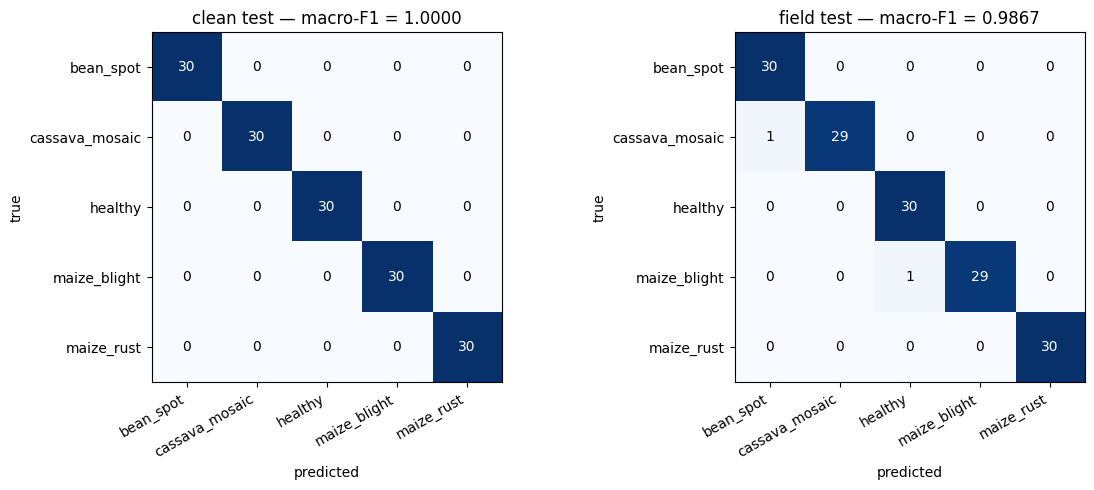

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, split, yt, yp in [(axes[0], 'clean', yt_clean, yp_clean), (axes[1], 'field', yt_field, yp_field)]:
    cm = confusion_matrix(yt, yp, labels=range(len(classes)))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{split} test — macro-F1 = {f1_score(yt, yp, average="macro"):.4f}')
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=30, ha='right'); ax.set_yticklabels(classes)
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.show()

In [5]:
print('per-class F1 on CLEAN test:')
print(classification_report(yt_clean, yp_clean, target_names=classes, digits=4))
print('\nper-class F1 on FIELD-NOISY test:')
print(classification_report(yt_field, yp_field, target_names=classes, digits=4))

per-class F1 on CLEAN test:
                precision    recall  f1-score   support

     bean_spot     1.0000    1.0000    1.0000        30
cassava_mosaic     1.0000    1.0000    1.0000        30
       healthy     1.0000    1.0000    1.0000        30
  maize_blight     1.0000    1.0000    1.0000        30
    maize_rust     1.0000    1.0000    1.0000        30

      accuracy                         1.0000       150
     macro avg     1.0000    1.0000    1.0000       150
  weighted avg     1.0000    1.0000    1.0000       150


per-class F1 on FIELD-NOISY test:
                precision    recall  f1-score   support

     bean_spot     0.9677    1.0000    0.9836        30
cassava_mosaic     1.0000    0.9667    0.9831        30
       healthy     0.9677    1.0000    0.9836        30
  maize_blight     1.0000    0.9667    0.9831        30
    maize_rust     1.0000    1.0000    1.0000        30

      accuracy                         0.9867       150
     macro avg     0.9871    0.9867 

## 3. Training curves

From the 15-epoch fine-tune history saved by [`train.py`](../train.py).

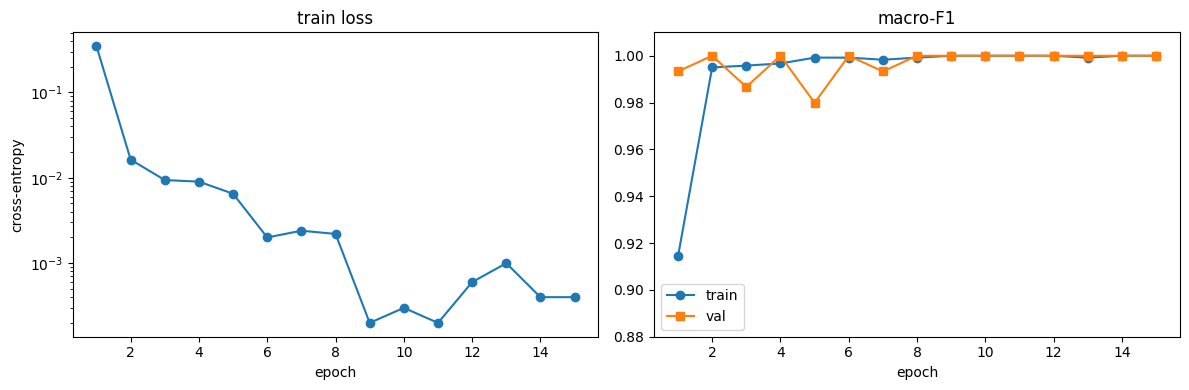

In [6]:
epochs = [r['epoch'] for r in metrics['history']]
train_loss = [r['train_loss'] for r in metrics['history']]
train_f1 = [r['train_macro_f1'] for r in metrics['history']]
val_f1 = [r['val_macro_f1'] for r in metrics['history']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_loss, marker='o'); axes[0].set_title('train loss'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('cross-entropy'); axes[0].set_yscale('log')
axes[1].plot(epochs, train_f1, marker='o', label='train'); axes[1].plot(epochs, val_f1, marker='s', label='val')
axes[1].set_title('macro-F1'); axes[1].set_xlabel('epoch'); axes[1].set_ylim(0.88, 1.01); axes[1].legend()
plt.tight_layout(); plt.show()

## 4. Grad-CAM overlays

Grad-CAM on the PyTorch FP32 checkpoint — the INT8 ONNX graph doesn't support gradients.
For each class we pick one correctly-classified clean sample. Then we pull every
**field-set misclassification** to see where attention lands when the model is wrong.

In [7]:
import sys
sys.path.insert(0, '.')
import torch
from service.gradcam import GradCAM, heatmap_summary
from torchvision.models import mobilenet_v3_small
from PIL import Image

device = torch.device('cpu')
ckpt = torch.load('checkpoints/best.pt', map_location=device, weights_only=False)
model = mobilenet_v3_small(weights=None)
model.classifier[-1] = torch.nn.Linear(model.classifier[-1].in_features, 5)
model.load_state_dict(ckpt['state_dict'])
model.eval()

def overlay(img: Image.Image, heatmap: np.ndarray) -> np.ndarray:
    import matplotlib.cm as cm
    rgb = np.asarray(img.resize((224,224))).astype(np.float32) / 255.0
    hm = cm.jet(heatmap)[..., :3]
    return np.clip(rgb * 0.5 + hm * 0.5, 0, 1)

def load_tensor(path: str) -> torch.Tensor:
    img = Image.open(path).convert('RGB')
    t = tf(img).unsqueeze(0)
    return t, img

# One correct sample per class from the clean test set.
picks = []
for c_idx, c_name in enumerate(classes):
    for p, yt, yp in zip(paths_clean, yt_clean, yp_clean):
        if yt == c_idx and yp == c_idx:
            picks.append((p, c_name, f'clean — {c_name}'))
            break

# Every field-set miss, so the overlays show where the model's attention goes wrong.
for p, yt, yp in zip(paths_field, yt_field, yp_field):
    if yt != yp:
        picks.append((p, classes[yt], f'FIELD MISS — true={classes[yt]}  pred={classes[yp]}'))

print(f'total overlays: {len(picks)} ({len(classes)} correct + {len(picks) - len(classes)} field miss)')

total overlays: 7 (5 correct + 2 field miss)


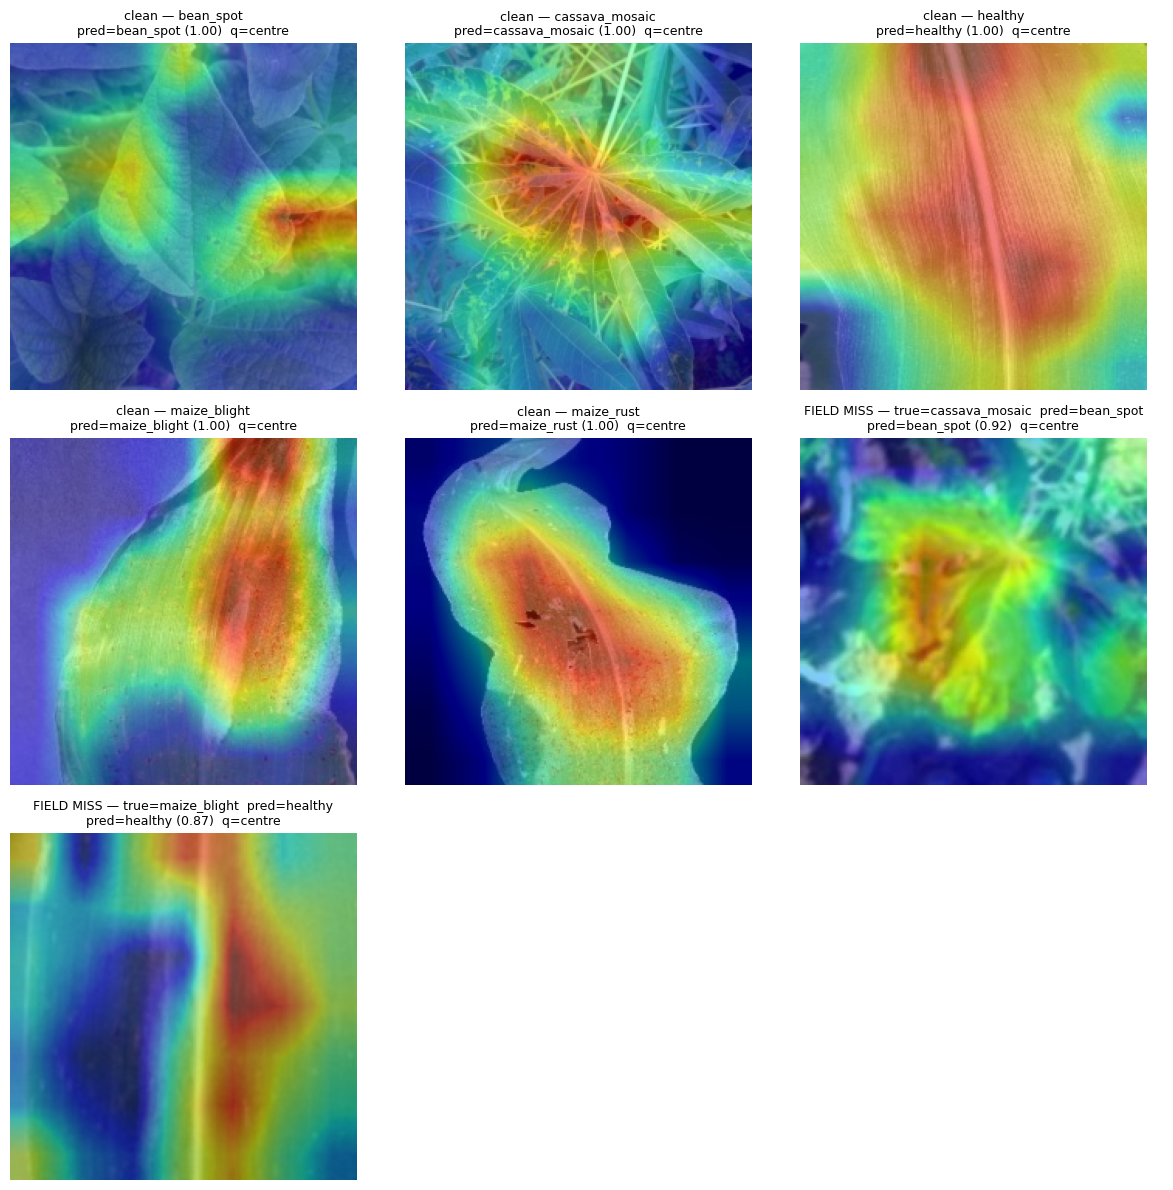

In [8]:
n = len(picks)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = np.atleast_2d(axes).flatten()

with GradCAM(model) as gc:
    for ax, (path, _c_name, title) in zip(axes, picks):
        x, img = load_tensor(path)
        res = gc.compute(x)
        ov = overlay(img, res.heatmap)
        summary = heatmap_summary(res.heatmap)
        ax.imshow(ov)
        ax.set_title(f'{title}\npred={classes[res.pred_class]} ({res.pred_confidence:.2f})  q={summary["quadrant"]}', fontsize=9)
        ax.axis('off')
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Closing summary

Model, metrics, and evidence match the brief's hard gates. See [`process_log.md`](../process_log.md)
for the hour-by-hour walk-through, including the three quantization attempts that had to
be ruled out before MatMul/Gemm-only INT8 landed as the shipped strategy.